In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import matplotlib.pyplot as plt
import awkward           as ak
import numpy             as np

from nHits_trigger.src.read_data          import nHits, read_mpmt_offsets
from WCTE_BRB_Data_Analysis.wcte.brbtools import sort_run_files, get_part_files
from matplotlib.backends.backend_pdf      import PdfPages

from tqdm import tqdm

plt.style.use('default');
pltext.style()

# Read Data And Correct TOF

In [2]:
bkg_run = 1766

bkg_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{bkg_run}/WCTE_offline_R{bkg_run}S*P*.root")
bkg_part_files = get_part_files(bkg_run_files)

# Run Variables
bkg_run_corrected_times           = []
bkg_run_hit_charges               = []
bkg_run_hit_card_ids              = []
bkg_run_hit_channel_ids           = []
bkg_run_hit_slot_ids              = []
bkg_run_hit_position_ids          = []
bkg_run_hit_pmt_has_time_constant = []

ev_offset = 0
for part in bkg_part_files[:1]:
    print(f"Processing part WCTE_offline_R{bkg_run}S0P{part}")
    bkg_tree = uproot.open(bkg_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    bkg_file_hit_card_ids              = ak.values_astype(bkg_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    bkg_file_hit_channel_ids           = ak.values_astype(bkg_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    bkg_file_hit_times                 = ak.values_astype(bkg_tree["hit_pmt_times"]            .array(), np.float64)
    bkg_file_hit_times_calib           = ak.values_astype(bkg_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    bkg_file_hit_charges               = ak.values_astype(bkg_tree["hit_pmt_charges"]          .array(), np.float64)
    bkg_file_hit_slot_ids              = ak.values_astype(bkg_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    bkg_file_hit_position_ids          = ak.values_astype(bkg_tree["hit_pmt_position_ids"]     .array(), np.int16)
    bkg_file_hit_pmt_has_time_constant = ak.values_astype(bkg_tree["hit_pmt_has_time_constant"].array(), np.bool)

    mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1767.json")

    max_slot = 106
    max_pos  = 19

    # Build lookup
    lookup = np.zeros((max_slot, max_pos))
    for (card, chan), shift in mpmt_map.items():
        lookup[card, chan] = shift

    # Hit Times Correction
    bkg_flat_slot_ids     = ak.ravel(bkg_file_hit_slot_ids)
    bkg_flat_pos_ids      = ak.ravel(bkg_file_hit_position_ids)
    bkg_flat_corrections  = lookup[bkg_flat_slot_ids, bkg_flat_pos_ids]
    bkg_corrections       = ak.unflatten(bkg_flat_corrections, ak.num(bkg_file_hit_card_ids))

    bkg_term1           = bkg_file_hit_times_calib
    bkg_corrected_times = bkg_term1 #- bkg_corrections 

    # Filter Out Main Things
    mask = (bkg_file_hit_charges < 1e4) & (bkg_file_hit_card_ids < 120) & (bkg_file_hit_pmt_has_time_constant != 0)
    bkg_corrected_times                = bkg_corrected_times                [mask]
    bkg_file_hit_charges               = bkg_file_hit_charges               [mask]
    bkg_file_hit_card_ids              = bkg_file_hit_card_ids              [mask]
    bkg_file_hit_channel_ids           = bkg_file_hit_channel_ids           [mask]
    bkg_file_hit_slot_ids              = bkg_file_hit_slot_ids              [mask]
    bkg_file_hit_position_ids          = bkg_file_hit_position_ids          [mask]
    bkg_file_hit_pmt_has_time_constant = bkg_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(bkg_corrected_times)
    
    bkg_run_corrected_times          .append(bkg_corrected_times               [order])
    bkg_run_hit_charges              .append(bkg_file_hit_charges              [order])
    bkg_run_hit_card_ids             .append(bkg_file_hit_card_ids             [order])    
    bkg_run_hit_channel_ids          .append(bkg_file_hit_channel_ids          [order]) 
    bkg_run_hit_slot_ids             .append(bkg_file_hit_slot_ids             [order])    
    bkg_run_hit_position_ids         .append(bkg_file_hit_position_ids         [order])
    bkg_run_hit_pmt_has_time_constant.append(bkg_file_hit_pmt_has_time_constant[order])

bkg_run_corrected_times           = ak.concatenate(bkg_run_corrected_times          )
bkg_run_hit_charges               = ak.concatenate(bkg_run_hit_charges              )
bkg_run_hit_card_ids              = ak.concatenate(bkg_run_hit_card_ids             )
bkg_run_hit_channel_ids           = ak.concatenate(bkg_run_hit_channel_ids          )
bkg_run_hit_slot_ids              = ak.concatenate(bkg_run_hit_slot_ids             )
bkg_run_hit_position_ids          = ak.concatenate(bkg_run_hit_position_ids         )
bkg_run_hit_pmt_has_time_constant = ak.concatenate(bkg_run_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1766S0P0


In [3]:
nicf_run = 1767

nicf_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{nicf_run}/WCTE_offline_R{nicf_run}S*P*.root")
nicf_part_files = get_part_files(nicf_run_files)

# Run Variables
nicf_run_tof_corrected_times           = []
nicf_run_tof_hit_charges               = []
nicf_run_tof_hit_card_ids              = []
nicf_run_tof_hit_channel_ids           = []
nicf_run_tof_hit_slot_ids              = []
nicf_run_tof_hit_position_ids          = []
nicf_run_tof_hit_pmt_has_time_constant = []

ev_offset = 0
for part in nicf_part_files[:1]:
    print(f"Processing part WCTE_offline_R{nicf_run}S0P{part}")
    nicf_tree = uproot.open(nicf_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    nicf_file_hit_card_ids              = ak.values_astype(nicf_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    nicf_file_hit_channel_ids           = ak.values_astype(nicf_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    nicf_file_hit_times                 = ak.values_astype(nicf_tree["hit_pmt_times"]            .array(), np.float64)
    nicf_file_hit_times_calib           = ak.values_astype(nicf_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    nicf_file_hit_charges               = ak.values_astype(nicf_tree["hit_pmt_charges"]          .array(), np.float64)
    nicf_file_hit_slot_ids              = ak.values_astype(nicf_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    nicf_file_hit_position_ids          = ak.values_astype(nicf_tree["hit_pmt_position_ids"]     .array(), np.int16)
    nicf_file_hit_pmt_has_time_constant = ak.values_astype(nicf_tree["hit_pmt_has_time_constant"].array(), np.bool)

    mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1767.json")

    max_slot = 106
    max_pos  = 19

    # Build lookup
    lookup = np.zeros((max_slot, max_pos))
    for (card, chan), shift in mpmt_map.items():
        lookup[card, chan] = shift

    # Hit Times Correction
    nicf_flat_slot_ids     = ak.ravel(nicf_file_hit_slot_ids)
    nicf_flat_pos_ids      = ak.ravel(nicf_file_hit_position_ids)
    nicf_flat_corrections  = lookup[nicf_flat_slot_ids, nicf_flat_pos_ids]
    nicf_corrections       = ak.unflatten(nicf_flat_corrections, ak.num(nicf_file_hit_card_ids))

    nicf_term1           = nicf_file_hit_times_calib
    nicf_corrected_times = nicf_term1 - nicf_corrections 

    # Filter Out Main Things
    mask = (nicf_file_hit_charges < 1e4) & (nicf_file_hit_card_ids < 120) & (nicf_file_hit_pmt_has_time_constant != 0)
    nicf_corrected_times                = nicf_corrected_times                [mask]
    nicf_file_hit_charges               = nicf_file_hit_charges               [mask]
    nicf_file_hit_card_ids              = nicf_file_hit_card_ids              [mask]
    nicf_file_hit_channel_ids           = nicf_file_hit_channel_ids           [mask]
    nicf_file_hit_slot_ids              = nicf_file_hit_slot_ids              [mask]
    nicf_file_hit_position_ids          = nicf_file_hit_position_ids          [mask]
    nicf_file_hit_pmt_has_time_constant = nicf_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(nicf_corrected_times)
    
    nicf_run_tof_corrected_times          .append(nicf_corrected_times               [order])
    nicf_run_tof_hit_charges              .append(nicf_file_hit_charges              [order])
    nicf_run_tof_hit_card_ids             .append(nicf_file_hit_card_ids             [order])    
    nicf_run_tof_hit_channel_ids          .append(nicf_file_hit_channel_ids          [order]) 
    nicf_run_tof_hit_slot_ids             .append(nicf_file_hit_slot_ids             [order])    
    nicf_run_tof_hit_position_ids         .append(nicf_file_hit_position_ids         [order])
    nicf_run_tof_hit_pmt_has_time_constant.append(nicf_file_hit_pmt_has_time_constant[order])

nicf_run_tof_corrected_times           = ak.concatenate(nicf_run_tof_corrected_times          )
nicf_run_tof_hit_charges               = ak.concatenate(nicf_run_tof_hit_charges              )
nicf_run_tof_hit_card_ids              = ak.concatenate(nicf_run_tof_hit_card_ids             )
nicf_run_tof_hit_channel_ids           = ak.concatenate(nicf_run_tof_hit_channel_ids          )
nicf_run_tof_hit_slot_ids              = ak.concatenate(nicf_run_tof_hit_slot_ids             )
nicf_run_tof_hit_position_ids          = ak.concatenate(nicf_run_tof_hit_position_ids         )
nicf_run_tof_hit_pmt_has_time_constant = ak.concatenate(nicf_run_tof_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1767S0P0


In [4]:
nicf_triggered_spill_hits_index_tof, nicf_triggered_spill_hit_times_tof = nHits(mode="multiple_events", hit_times=nicf_run_tof_corrected_times, w=5000, thresh_min=300, thresh_max=100000, pre_window=0, post_window=4000, jump=9000)
bkg_triggered_spill_hits_index, bkg_triggered_spill_hit_times           = nHits(mode="multiple_events", hit_times=bkg_run_corrected_times,      w=5000, thresh_min=300, thresh_max=100000, pre_window=0, post_window=4000, jump=9000)

  0%|          | 0/11113 [00:00<?, ?it/s]

100%|██████████| 11113/11113 [00:03<00:00, 2988.85it/s]


### Remove Spills from data

In [5]:
def remove_spill(trigger_indices, run_times):
    corrected_run_times = []

    for i in tqdm(range(len(run_times))):
        if i in trigger_indices:
            #Event with spill → remove selected indices
            if len(trigger_indices[i]) > 0:
                data = run_times[i]
                trigger_indices_event = np.concatenate(trigger_indices[i])
                all_indices           = np.arange(len(data))
                valid_indices         = np.setdiff1d(all_indices, trigger_indices_event)
                corrected_run_times.append(data[valid_indices])
            
            else:
                continue
        else:
            # Event without spill → leave as it is
            corrected_run_times.append(run_times[i])

    return ak.Array(corrected_run_times)

In [6]:
# Hit Time
nicf_noSpill_times_tof = remove_spill(nicf_triggered_spill_hits_index_tof, nicf_run_tof_corrected_times)
bkg_noSpill_times      = remove_spill(bkg_triggered_spill_hits_index, bkg_run_corrected_times)

100%|██████████| 11113/11113 [00:02<00:00, 5013.01it/s]


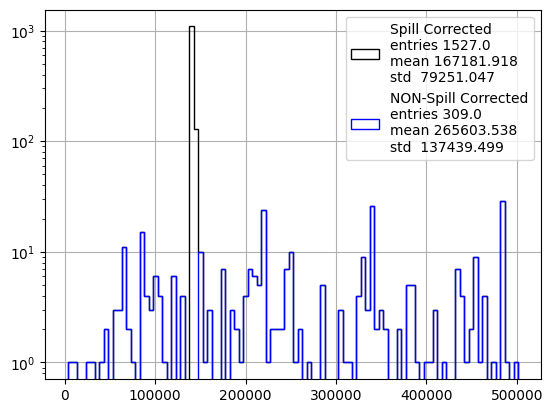

In [7]:
pltext.hist(nicf_run_tof_corrected_times[0], 100, ylog=True, label="Spill Corrected");
pltext.hist(nicf_noSpill_times_tof[0],       100, ylog=True, label="NON-Spill Corrected");

In [8]:
def nHits(mode,
          hit_times,
          w,
          thresh_min,
          thresh_max,
          pre_window,
          post_window,
          jump,
          event=0,
          progress_bar=True):

    def process_event(ht,
                      w,
                      thresh_min,
                      thresh_max,
                      pre_window,
                      post_window,
                      jump):

        if len(ht) == 0:
            return [], [], [], []

        # Orden temporal
        ht = np.sort(ht)

        # ------------------------
        # Sliding window trigger
        # ------------------------

        ends = ht + w
        right = np.searchsorted(ht, ends, side="left")
        left = np.arange(len(ht))
        counts = right - left

        trigger_indices = np.where(counts >= thresh_min)[0]

        triggered_hits_index = []
        triggered_hits_time = []

        trigger_seeds = []      # t_seed (paper SLE crossing)
        roi_start_times = []   # primer hit físico del cluster

        last_cluster_end = -np.inf

        # ------------------------
        # Loop triggers
        # ------------------------

        for idx in trigger_indices:

            t_seed = ht[idx]

            # Deadtime basado en CLUSTER REAL
            if t_seed < last_cluster_end + jump:
                continue

            # ------------------------
            # ROI física
            # ------------------------

            t_min = t_seed - pre_window
            t_max = t_seed + w + post_window

            roi_mask = (ht >= t_min) & (ht <= t_max)
            indices_roi = np.where(roi_mask)[0]

            if len(indices_roi) < thresh_min:
                continue
            
            if thresh_max is not None and len(indices_roi) > thresh_max:
                continue

            hit_times_roi = ht[indices_roi]

            # ------------------------
            # Guardado
            # ------------------------

            triggered_hits_index.append(indices_roi)
            triggered_hits_time.append(hit_times_roi)

            trigger_seeds.append(t_seed)
            roi_start_times.append(hit_times_roi[0])

            # Deadtime real: fin del cluster físico
            last_cluster_end = hit_times_roi[-1]

        return triggered_hits_index, triggered_hits_time, trigger_seeds, roi_start_times

    # ==================================================
    # SINGLE EVENT
    # ==================================================

    if mode == "single_event":

        ht = ak.to_numpy(hit_times[event])

        idxs, times, seeds, roi_starts = process_event(
            ht,
            w,
            thresh_min,
            thresh_max,
            pre_window,
            post_window,
            jump
        )

        return ({event: idxs},
                {event: times},
                {event: seeds},
                {event: roi_starts})

    # ==================================================
    # MULTIPLE EVENTS
    # ==================================================

    elif mode == "multiple_events":

        nevents = len(hit_times)

        triggered_hits_index = {}
        triggered_hits_time = {}
        trigger_seeds_dict = {}
        roi_start_times_dict = {}

        for event in tqdm(range(nevents),
                          total=nevents,
                          leave=progress_bar):

            ht = ak.to_numpy(hit_times[event])

            if len(ht) == 0:
                triggered_hits_index[event] = []
                triggered_hits_time[event] = []
                trigger_seeds_dict[event] = []
                roi_start_times_dict[event] = []
                continue

            idxs, times, seeds, roi_starts = process_event(
                ht,
                w,
                thresh_min,
                thresh_max,
                pre_window,
                post_window,
                jump
            )

            triggered_hits_index[event] = idxs
            triggered_hits_time[event] = times
            trigger_seeds_dict[event] = seeds
            roi_start_times_dict[event] = roi_starts

        return (triggered_hits_index,
                triggered_hits_time,
                trigger_seeds_dict,
                roi_start_times_dict)

    else:
        print("enter a valid mode name")
        return {}, {}, {}, {}


In [24]:
thresh_inf          = 5   # hits
thresh_sup          = 60   # hits
sliding_window      = 20   # ns
pre_trigger_window  = 200
post_trigger_window = 200
dead_time           = pre_trigger_window + post_trigger_window    # ns

# nHits
nicf_triggered_signal_hits_index_tof, nicf_triggered_signal_hit_times_tof, nicf_d_seed_tof, nicf_d_roi_tof = nHits(mode="multiple_events", hit_times=nicf_noSpill_times_tof, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time)
bkg_triggered_signal_hits_index_tof, bkg_triggered_signal_hit_times_tof, bkg_d_seed_tof, bkg_d_roi_tof     = nHits(mode="multiple_events", hit_times=bkg_noSpill_times,      w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time)

# tRMS
nicf_rms_50ns_tof  = []
nicf_50ns_size_tof = []
for k,v in tqdm(nicf_triggered_signal_hit_times_tof.items(), total=len(nicf_triggered_signal_hit_times_tof.items()), leave=False):
        for i in nicf_triggered_signal_hit_times_tof.get(k):
            nicf_rms_50ns_tof.append(np.std(i, ddof=0))
            nicf_50ns_size_tof.append(len(i))

bkg_rms_50ns  = []
bkg_50ns_size = []
for k,v in tqdm(bkg_triggered_signal_hit_times_tof.items(), total=len(bkg_triggered_signal_hit_times_tof.items()), leave=False):
        for i in bkg_triggered_signal_hit_times_tof.get(k):
            bkg_rms_50ns.append(np.std(i, ddof=0))
            bkg_50ns_size.append(len(i))

100%|██████████| 11113/11113 [00:04<00:00, 2729.32it/s]


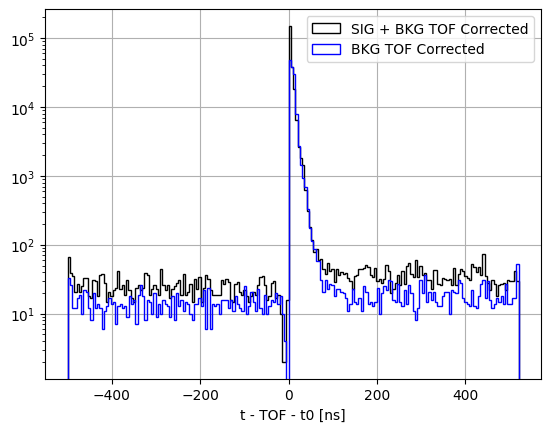

In [10]:
c_nicf_tof = []
for k,v in nicf_triggered_signal_hit_times_tof.items():
    event = k
    if len(nicf_triggered_signal_hit_times_tof[event])>0:
        c_nicf_tof.append(nicf_triggered_signal_hit_times_tof[event][0] - nicf_d_seed_tof[event][0])

c_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof.items():
    event = k
    if len(bkg_triggered_signal_hit_times_tof[event])>0:
        c_bkg.append(bkg_triggered_signal_hit_times_tof[event][0] - bkg_d_seed_tof[event][0])

pltext.hist(np.concatenate(c_nicf_tof), 200, ylog=True, xylabels="t - TOF - t0 [ns]", stats=False, label="SIG + BKG TOF Corrected");
pltext.hist(np.concatenate(c_bkg),      200, ylog=True, xylabels="t - TOF - t0 [ns]", stats=False, label="BKG TOF Corrected");

In [11]:
a = []
b = []
for k,v in nicf_triggered_signal_hit_times_tof.items():
    event = k
    sett  = v

    for i in range(len(sett)):

        diffa = (sett[i] - min(sett[i])) - (nicf_d_seed_tof[event][i] - min(sett[i]))
        diffb = sett[i] - nicf_d_seed_tof[event][i]
        a.append(diffa)
        b.append(diffb)

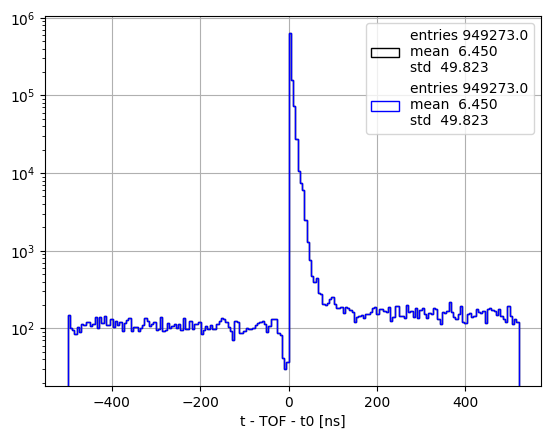

In [12]:
pltext.hist(np.concatenate(a), 200, ylog=True, xylabels="t - TOF - t0 [ns]",);
pltext.hist(np.concatenate(b), 200, ylog=True);

# New $t_0$ definition

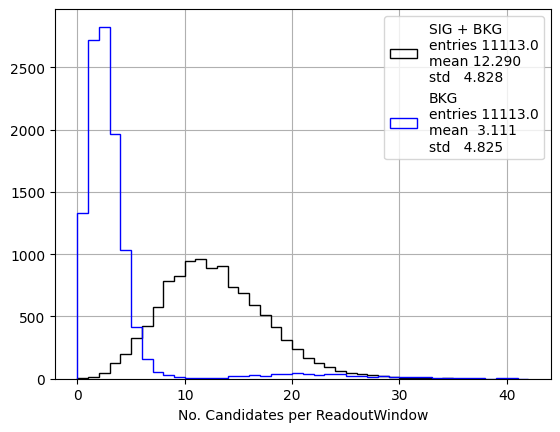

In [25]:
# 2. Cuántos candidatos hay en una readout window?
candidates_per_redaoutWindow_sig = []
for k,v in nicf_triggered_signal_hit_times_tof.items():
    candidates_per_redaoutWindow_sig.append(len(v))

candidates_per_redaoutWindow_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof.items():
    candidates_per_redaoutWindow_bkg.append(len(v))

pltext.hist(candidates_per_redaoutWindow_sig, np.max(candidates_per_redaoutWindow_sig), xylabels="No. Candidates per ReadoutWindow", label="SIG + BKG");
pltext.hist(candidates_per_redaoutWindow_bkg, np.max(candidates_per_redaoutWindow_bkg), xylabels="No. Candidates per ReadoutWindow", label="BKG");

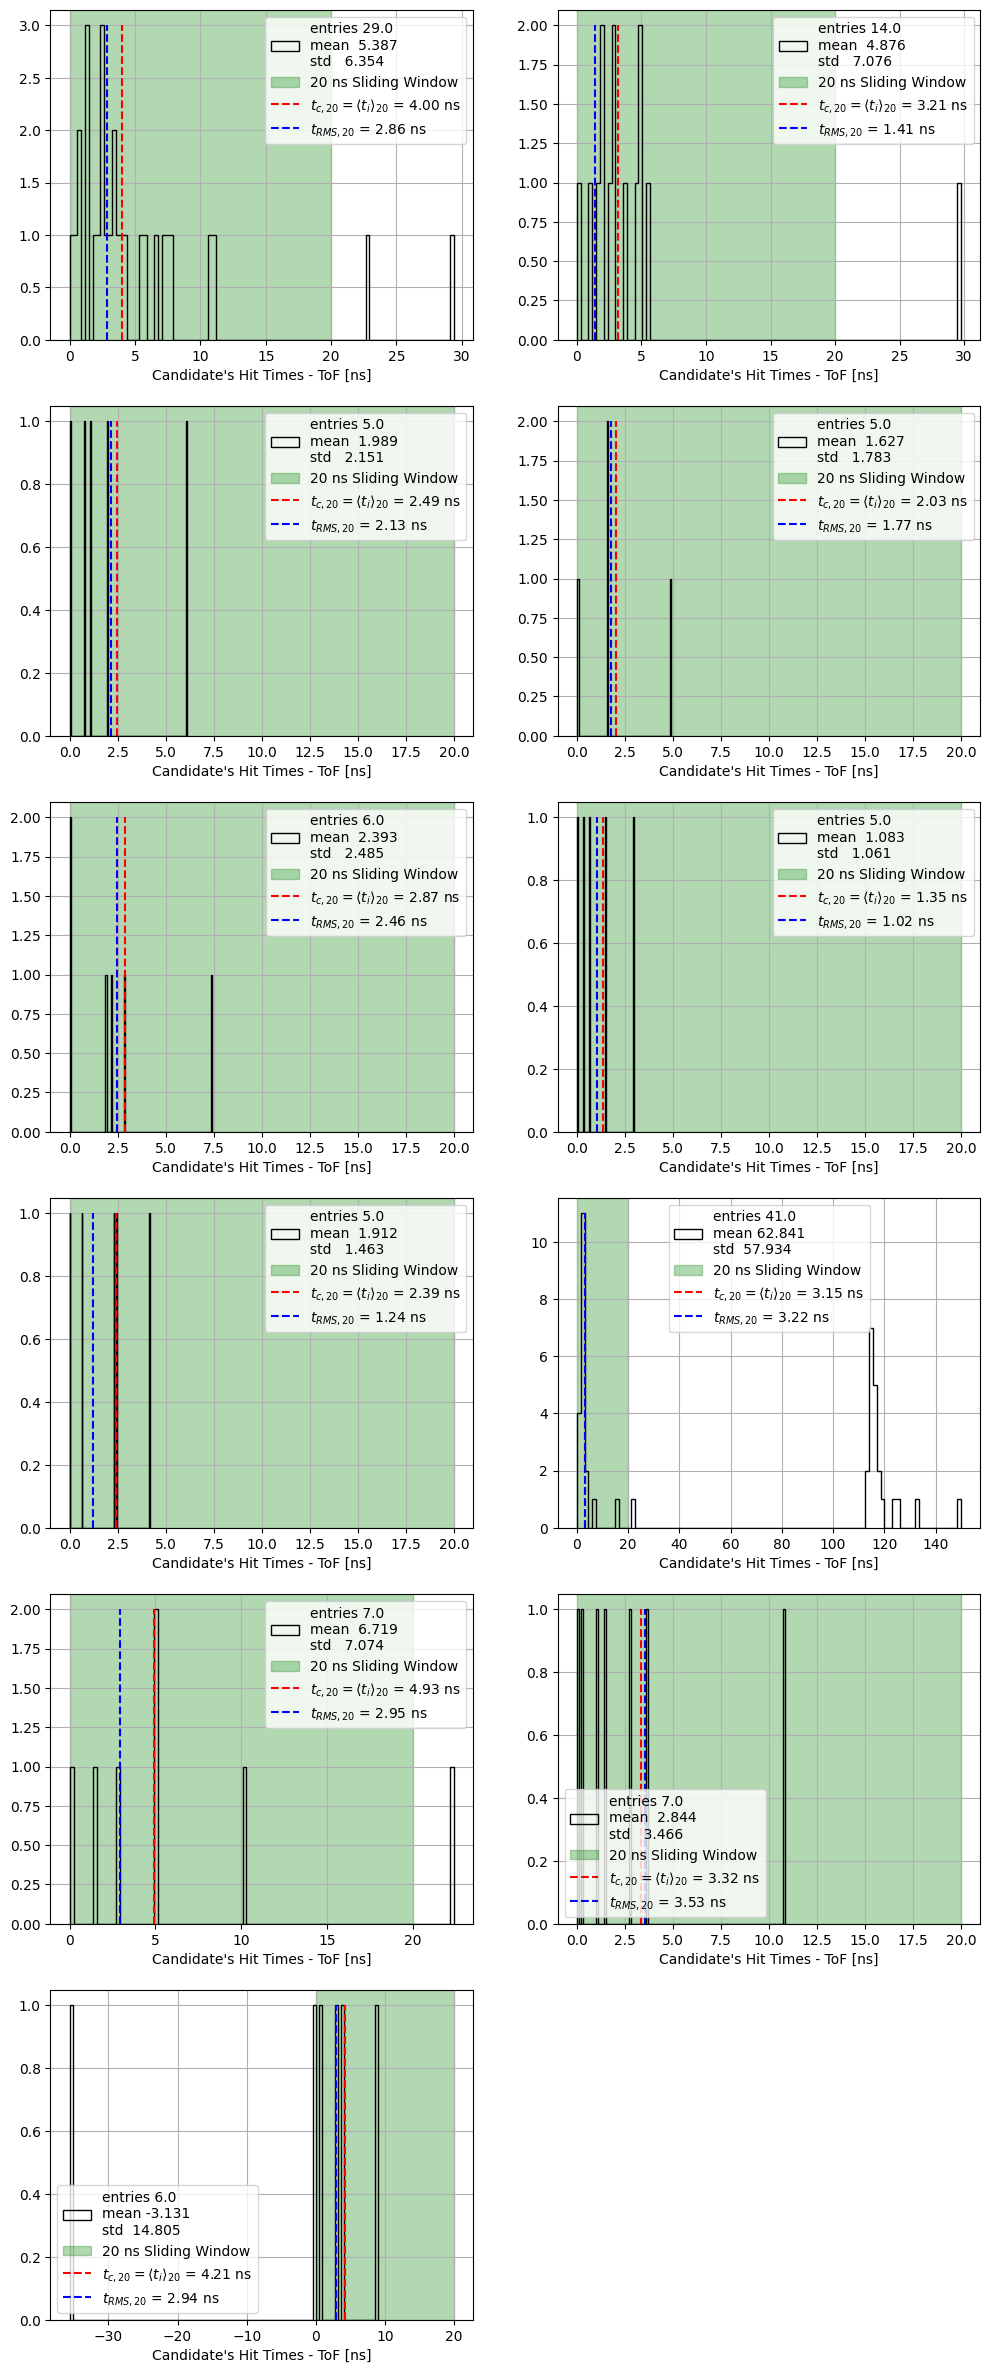

In [34]:
# 1. Calcular el t0 de ese candidato como el promedio del tiempo de sus hits (los que están en la venta).

event = 18
sett  = nicf_triggered_signal_hit_times_tof[event] 
seed  = nicf_d_seed_tof[event]
roi   = nicf_d_roi_tof[event]
subplot = pltext.canvas(len(sett))

for i in range(len(sett)):

    shifted_sett = sett[i] - seed[i]
    shifted_seed = seed[i] - seed[i]

    mask  = (shifted_sett > shifted_seed) & (shifted_sett < shifted_seed+20)
    t0    = np.mean(sett[i])
    t0_20 = np.mean(shifted_sett[mask])
    trms_20  = np.std(shifted_sett[mask])
    

    subplot(i+1)
    # h = pltext.hist(sett[i][mask], 100, xylabels="Candidate's Hit Times [ns]");
    h = pltext.hist(shifted_sett, 100, xylabels="Candidate's Hit Times - ToF [ns]");
    plt.axvspan(shifted_seed, shifted_seed+20, color="green", alpha=0.3, label="20 ns Sliding Window");
    # plt.axvspan(shifted_seed, shifted_seed-200, color="yellow", alpha=0.3, label="200 ns PreTrigger Window");
    # plt.axvspan(shifted_seed+20, shifted_seed+20+200, color="red", alpha=0.3, label="200 ns PosTrigger Window");
    plt.vlines(t0_20, 0, np.max(h[0]), color="red", linestyles="--", label=rf"$t_{{c, 20}} = \langle t_i \rangle_{{20}}$ = {t0_20:.2f} ns")
    plt.vlines(trms_20, 0, np.max(h[0]), color="blue", linestyles="--", label=rf"$t_{{RMS, 20}}$ = {trms_20:.2f} ns")
    plt.legend();
    # plt.suptitle("Example ReadoutWindow With Four Candidates")

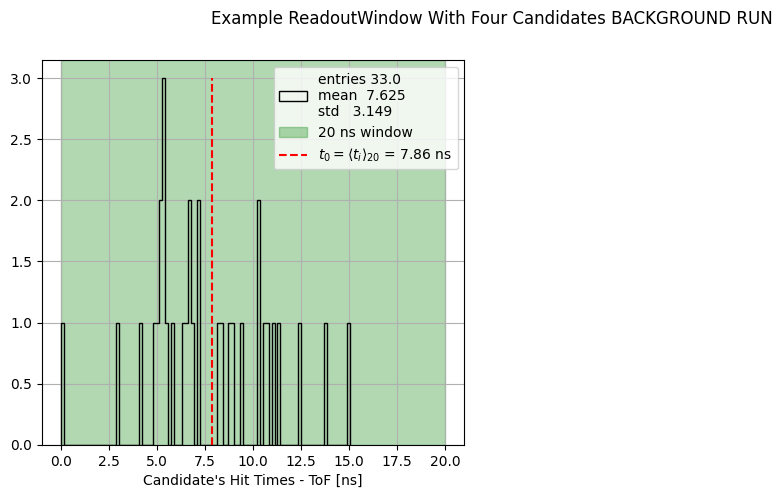

In [15]:
# 1. Calcular el t0 de ese candidato como el promedio del tiempo de sus hits (los que están en la venta).

event = 6
sett  = bkg_triggered_signal_hit_times_tof[event] 
seed  = bkg_d_seed_tof[event]
roi   = bkg_d_roi_tof[event]
subplot = pltext.canvas(len(sett))

for i in range(len(sett)):

    shifted_sett = sett[i] - seed[i]
    shifted_seed = seed[i] - seed[i]

    mask  = (shifted_sett > shifted_seed) & (shifted_sett < shifted_seed+20)
    t0    = np.mean(sett[i])
    t0_20 = np.mean(shifted_sett[mask])
    

    subplot(i+1)
    # h = pltext.hist(sett[i][mask], 100, xylabels="Candidate's Hit Times [ns]");
    h = pltext.hist(shifted_sett, 100, xylabels="Candidate's Hit Times - ToF [ns]");
    plt.axvspan(shifted_seed, shifted_seed+20, color="green", alpha=0.3, label="20 ns window");
    plt.vlines(t0_20, 0, np.max(h[0]), color="red", linestyles="--", label=rf"$t_0 = \langle t_i \rangle_{{20}}$ = {t0_20:.2f} ns")
    plt.legend();
    plt.suptitle("Example ReadoutWindow With Four Candidates BACKGROUND RUN")

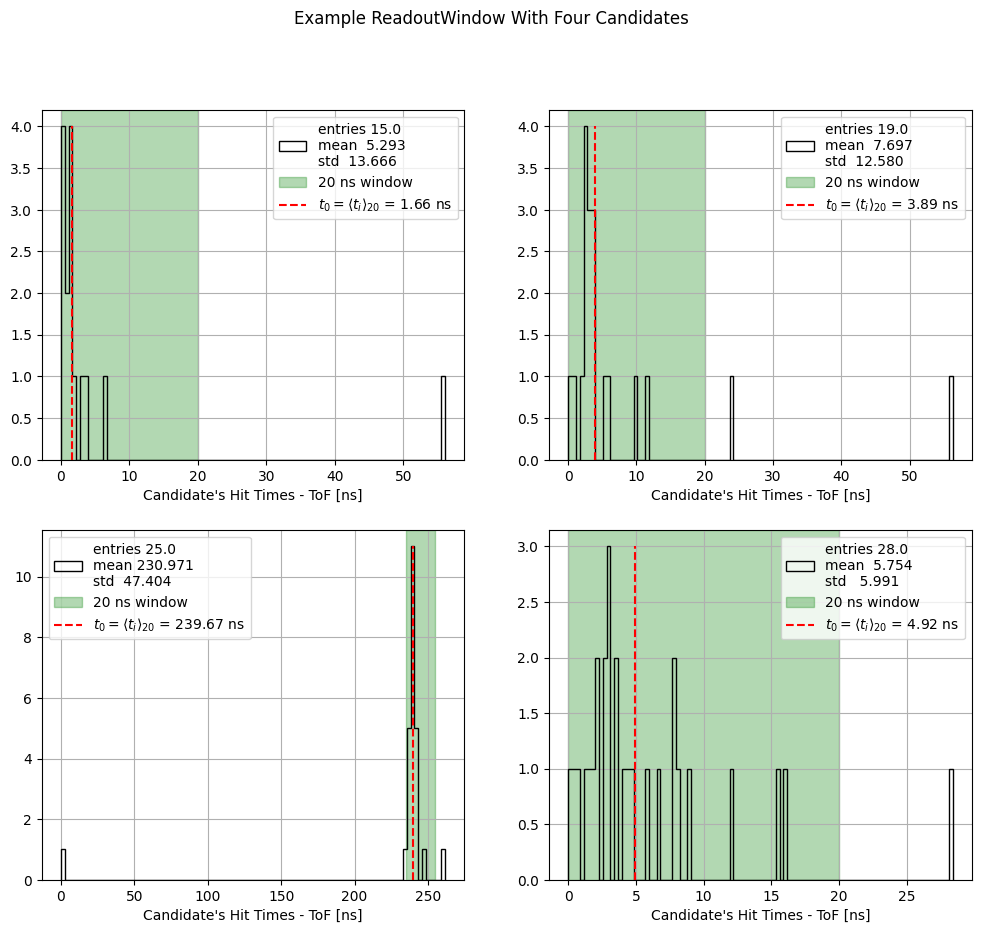

In [16]:
# 1. Calcular el t0 de ese candidato como el promedio del tiempo de sus hits (los que están en la venta).

event = 0
sett  = nicf_triggered_signal_hit_times_tof[event] 
seed  = nicf_d_seed_tof[event]
roi   = nicf_d_roi_tof[event]
subplot = pltext.canvas(len(sett))

for i in range(len(sett)):

    shifted_sett = sett[i] - min(sett[i])
    shifted_seed = seed[i] - min(sett[i])

    mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
    t0    = np.mean(sett[i])
    t0_20 = np.mean(shifted_sett[mask])

    subplot(i+1)
    # h = pltext.hist(sett[i][mask], 100, xylabels="Candidate's Hit Times [ns]");
    h = pltext.hist(shifted_sett, 100, xylabels="Candidate's Hit Times - ToF [ns]");
    plt.axvspan(shifted_seed, shifted_seed+20, color="green", alpha=0.3, label="20 ns window");
    plt.vlines(t0_20, 0, np.max(h[0]), color="red", linestyles="--", label=rf"$t_0 = \langle t_i \rangle_{{20}}$ = {t0_20:.2f} ns")
    plt.legend();
    plt.suptitle("Example ReadoutWindow With Four Candidates")

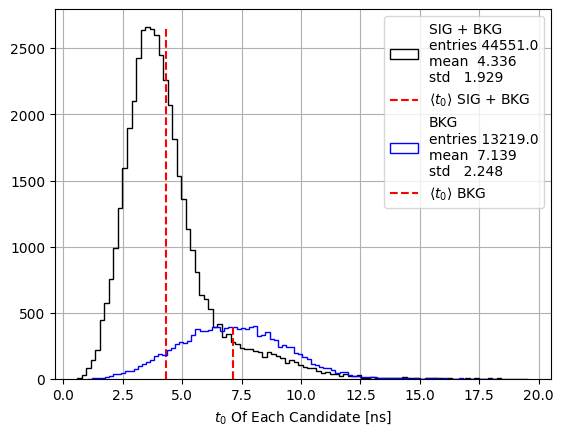

In [17]:
# 1. Calcular el t0 de ese candidato como el promedio del tiempo de sus hits (los que están en la venta).

t0_20_sig = []
for k,v in nicf_triggered_signal_hit_times_tof.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof[event] 
    seed  = nicf_d_seed_tof[event]
    roi   = nicf_d_roi_tof[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett > shifted_seed) & (shifted_sett < shifted_seed+20)
        mean_val = np.mean(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if mean_val is not None:
            t0_20_sig.append(mean_val)

t0_20_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof[event] 
    seed  = bkg_d_seed_tof[event]
    roi   = bkg_d_roi_tof[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett > shifted_seed) & (shifted_sett < shifted_seed+20)
        mean_val = np.mean(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if mean_val is not None:
            t0_20_bkg.append(mean_val)

h = pltext.hist(t0_20_sig, 100, ylog=False, xylabels="$t_0$ Of Each Candidate [ns]", label="SIG + BKG");
plt.vlines(np.mean(t0_20_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_0 \rangle$ SIG + BKG");
h = pltext.hist(t0_20_bkg, 100, ylog=False, xylabels="$t_0$ Of Each Candidate [ns]", label="BKG");
plt.vlines(np.mean(t0_20_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_0 \rangle$ BKG");
plt.legend();

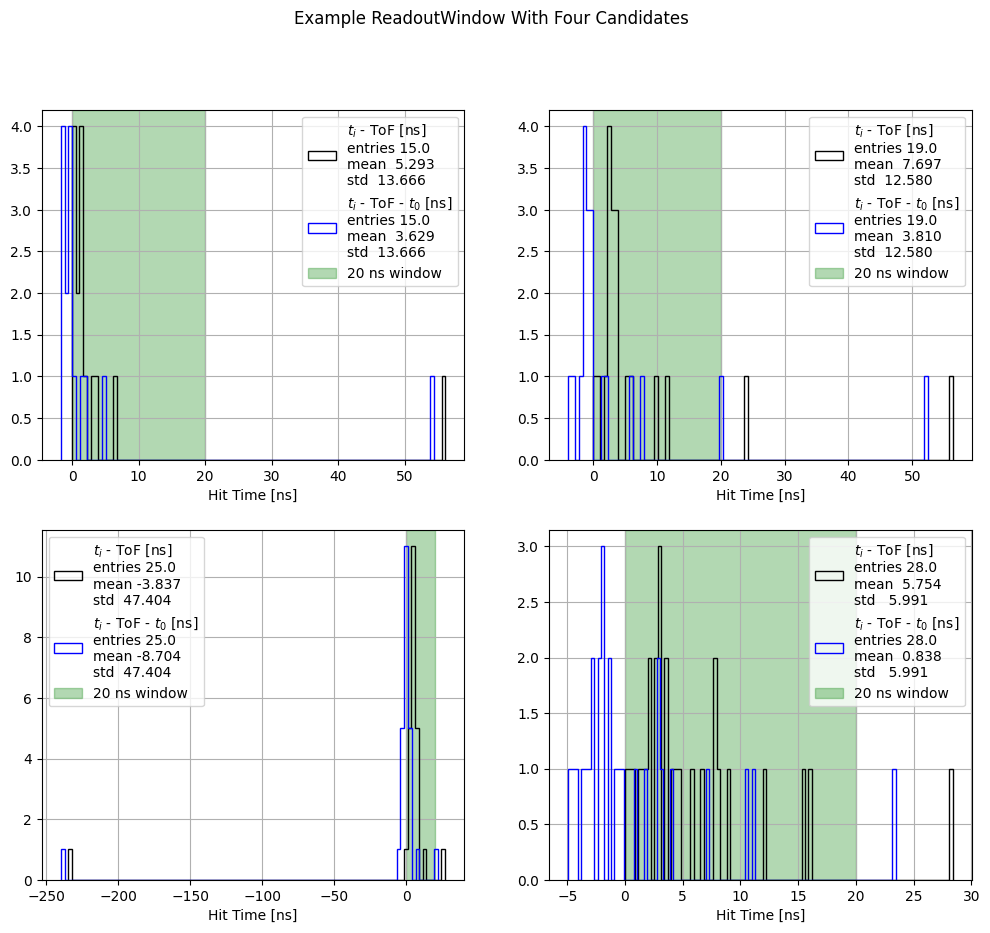

In [18]:
# Para los hits en la ventana larga calcular la distribución de t-tof-t0 de los hits. 
# A partir de la distribución a la izquierda del candidato (en el pre-trigger) podemos calcular el dark-rate, esto es, el número de hits/ns.

event = 0
sett  = nicf_triggered_signal_hit_times_tof[event] 
seed  = nicf_d_seed_tof[event]
roi   = nicf_d_roi_tof[event]
subplot = pltext.canvas(len(sett))

for i in range(len(sett)):

    shifted_sett = sett[i] - seed[i]
    shifted_seed = seed[i] - seed[i]

    mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
    t0_20 = np.mean(shifted_sett[mask])

    t_tof_to_20 = shifted_sett - t0_20
    

    subplot(i+1)
    h = pltext.hist(shifted_sett, 100, xylabels="Candidate's Hit Times - ToF [ns]", label="$t_i$ - ToF [ns]");
    pltext.hist(t_tof_to_20, 100, xylabels="Hit Time [ns]", label="$t_i$ - ToF - $t_0$ [ns]");
    plt.axvspan(shifted_seed, shifted_seed+20, color="green", alpha=0.3, label="20 ns window");
    plt.legend();
    plt.suptitle("Example ReadoutWindow With Four Candidates");

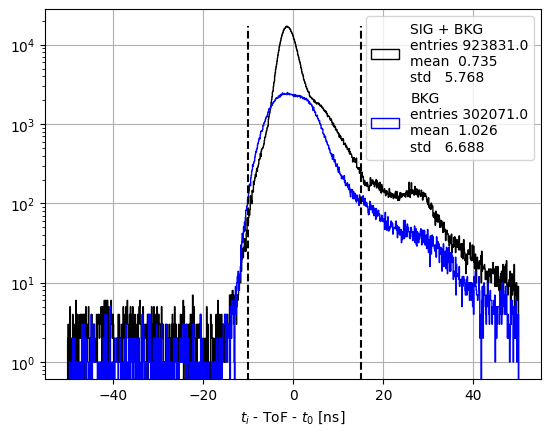

In [19]:
# Para los hits en la ventana larga calcular la distribución de t-tof-t0 de los hits. 
# A partir de la distribución a la izquierda del candidato (en el pre-trigger) podemos calcular el dark-rate, esto es, el número de hits/ns.

t_tof_to_20_sig = []

for k,v in nicf_triggered_signal_hit_times_tof.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof[event] 
    seed  = nicf_d_seed_tof[event]
    roi   = nicf_d_roi_tof[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        # t0_20 = np.mean(shifted_sett[mask])

        mean_val = np.mean(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if mean_val is not None:
            t0_20 = mean_val

        t_tof_to_20_sig.append(shifted_sett - t0_20)
        # t_tof_to_20_sig.append(shifted_sett - shifted_seed)

t_tof_to_20_bkg = []

for k,v in bkg_triggered_signal_hit_times_tof.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof[event] 
    seed  = bkg_d_seed_tof[event]
    roi   = bkg_d_roi_tof[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        # t0_20 = np.mean(shifted_sett[mask])

        mean_val = np.mean(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if mean_val is not None:
            t0_20 = mean_val

        t_tof_to_20_bkg.append(shifted_sett - t0_20)
        # t_tof_to_20_bkg.append(shifted_sett - shifted_seed)

hs = pltext.hist(np.concatenate(t_tof_to_20_sig), 1000, range=(-50, 50), ylog=True, xylabels="$t_i$ - ToF - $t_0$ [ns]", label="SIG + BKG");
hb = pltext.hist(np.concatenate(t_tof_to_20_bkg), 1000, range=(-50, 50), ylog=True, xylabels="$t_i$ - ToF - $t_0$ [ns]", label="BKG");

plt.vlines(-10, 0, np.max(hs[0]), color="black",   linestyles="--");
plt.vlines(15, 0, np.max(hs[0]), color="black", linestyles="--");
plt.legend();

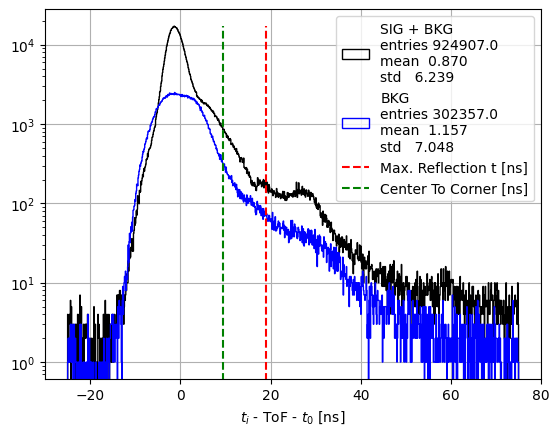

In [20]:
# Para los hits en la ventana larga calcular la distribución de t-tof-t0 de los hits. 
# A partir de la distribución a la izquierda del candidato (en el pre-trigger) podemos calcular el dark-rate, esto es, el número de hits/ns.

t_tof_to_20_sig = {}

for k,v in nicf_triggered_signal_hit_times_tof.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof[event] 
    seed  = nicf_d_seed_tof[event]
    roi   = nicf_d_roi_tof[event]

    t_tof_to_20_sig[event] = []

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        
        if np.any(mask):
            t0_20 = np.mean(shifted_sett[mask])
            t_tof_to_20_sig[event].append(shifted_sett - t0_20)

        # t_tof_to_20_sig.append(shifted_sett - shifted_seed)

t_tof_to_20_bkg = {}

for k,v in bkg_triggered_signal_hit_times_tof.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof[event] 
    seed  = bkg_d_seed_tof[event]
    roi   = bkg_d_roi_tof[event]

    t_tof_to_20_bkg[event] = []

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        
        if np.any(mask):
            t0_20 = np.mean(shifted_sett[mask])
            t_tof_to_20_bkg[event].append(shifted_sett - t0_20)
        # t_tof_to_20_bkg.append(shifted_sett - shifted_seed)

all_sig = np.concatenate(
    [arr for sublist in t_tof_to_20_sig.values() for arr in sublist]
)

all_bkg = np.concatenate(
    [arr for sublist in t_tof_to_20_bkg.values() for arr in sublist]
)

hs = pltext.hist(all_sig, 1000, range=(-25, 75), ylog=True, xylabels="$t_i$ - ToF - $t_0$ [ns]", label="SIG + BKG");
hb = pltext.hist(all_bkg, 1000, range=(-25, 75), ylog=True, xylabels="$t_i$ - ToF - $t_0$ [ns]", label="BKG");

plt.vlines(18.9, 0, np.max(hs[0]), color="red",   linestyles="--", label="Max. Reflection t [ns]");
plt.vlines(9.40, 0, np.max(hs[0]), color="green", linestyles="--", label="Center To Corner [ns]");
plt.legend();

In [21]:
# Podemos calcular por evento el número de hits pre-trigger (antes del t0) (npre) y post-trigger (después del t0) (npost). Hacer un scatter y un histograma de npre vs npost. 
# Esperaríamos que en los eventos de señal los dos coincidan y en el bkg haya más en el npost. 
# Si es así podemos usar la diferencia entre ambos npost-npre para seleccionar eventos de señal y eliminar el bkg. 

# event = 0
# sett  = nicf_triggered_signal_hit_times_tof[event] 
# seed  = nicf_d_seed_tof[event]
# roi   = nicf_d_roi_tof[event]
# # subplot = pltext.canvas(len(sett))

# for i in range(len(sett)):

#     shifted_sett = sett[i] - seed[i]
#     shifted_seed = seed[i] - seed[i]

#     mask_window = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
#     mask_post   = (shifted_sett > (shifted_seed+20))
#     mask_pre    = (shifted_sett < (shifted_seed))
#     t0_20       = np.mean(shifted_sett[mask_window])

#     print(f"Hits In Pre  Trigger: {shifted_sett[mask_pre]}")
#     print(f"Hits In Post Trigger: {shifted_sett[mask_post]}")
    
    # subplot(i+1)
    # h = pltext.hist(shifted_sett, 100, xylabels="Candidate's Hit Times - ToF [ns]");

    # plt.axvspan((shifted_sett)[mask_window][0], (shifted_sett)[mask_window][0]+20, color="green",  alpha=0.3, label="20 ns window");
    # plt.axvspan((shifted_sett)[mask_window][0]+20, (shifted_sett)[mask_post][-1],  color="red",    alpha=0.3, label="post window");
    # plt.axvspan((shifted_sett)[mask_pre][0], (shifted_sett)[mask_window][0],       color="yellow", alpha=0.3, label="pre window");

    # plt.vlines(t0_20, 0, np.max(h[0]), color="red", linestyles="--", label=r"$t_0 = \langle t_i \rangle_{20}$")
    # plt.legend();

In [22]:
# Podemos calcular por evento el número de hits pre-trigger (antes del t0) (npre) y post-trigger (después del t0) (npost). Hacer un scatter y un histograma de npre vs npost. 
# Esperaríamos que en los eventos de señal los dos coincidan y en el bkg haya más en el npost. 
# Si es así podemos usar la diferencia entre ambos npost-npre para seleccionar eventos de señal y eliminar el bkg. 

noHits_in_preTrigger_sig = []
noHits_in_posTrigger_sig = []

for k,v in nicf_triggered_signal_hit_times_tof.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof[event] 
    seed  = nicf_d_seed_tof[event]
    roi   = nicf_d_roi_tof[event]
    # subplot = pltext.canvas(len(sett))

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask_window = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        mask_post   = (shifted_sett > (shifted_seed+20))
        mask_pre    = (shifted_sett < (shifted_seed))
        t0_20       = np.mean(shifted_sett[mask_window])

        noHits_in_preTrigger_sig.append(len(shifted_sett[mask_pre]))
        noHits_in_posTrigger_sig.append(len(shifted_sett[mask_post]))
        
        # subplot(i+1)
        # h = pltext.hist(shifted_sett, 100, xylabels="Candidate's Hit Times - ToF [ns]");

        # plt.axvspan((shifted_sett)[mask_window][0], (shifted_sett)[mask_window][0]+20, color="green",  alpha=0.3, label="20 ns window");
        # plt.axvspan((shifted_sett)[mask_window][0]+20, (shifted_sett)[mask_post][-1],  color="red",    alpha=0.3, label="post window");
        # plt.axvspan((shifted_sett)[mask_pre][0], (shifted_sett)[mask_window][0],       color="yellow", alpha=0.3, label="pre window");

        # plt.vlines(t0_20, 0, np.max(h[0]), color="red", linestyles="--", label=r"$t_0 = \langle t_i \rangle_{20}$")
        # plt.legend();

noHits_in_preTrigger_bkg = []
noHits_in_posTrigger_bkg = []

for k,v in bkg_triggered_signal_hit_times_tof.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof[event] 
    seed  = bkg_d_seed_tof[event]
    roi   = bkg_d_roi_tof[event]
    # subplot = pltext.canvas(len(sett))

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask_window = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        mask_post   = (shifted_sett > (shifted_seed+20))
        mask_pre    = (shifted_sett < (shifted_seed))
        t0_20       = np.mean(shifted_sett[mask_window])

        noHits_in_preTrigger_bkg.append(len(shifted_sett[mask_pre]))
        noHits_in_posTrigger_bkg.append(len(shifted_sett[mask_post]))

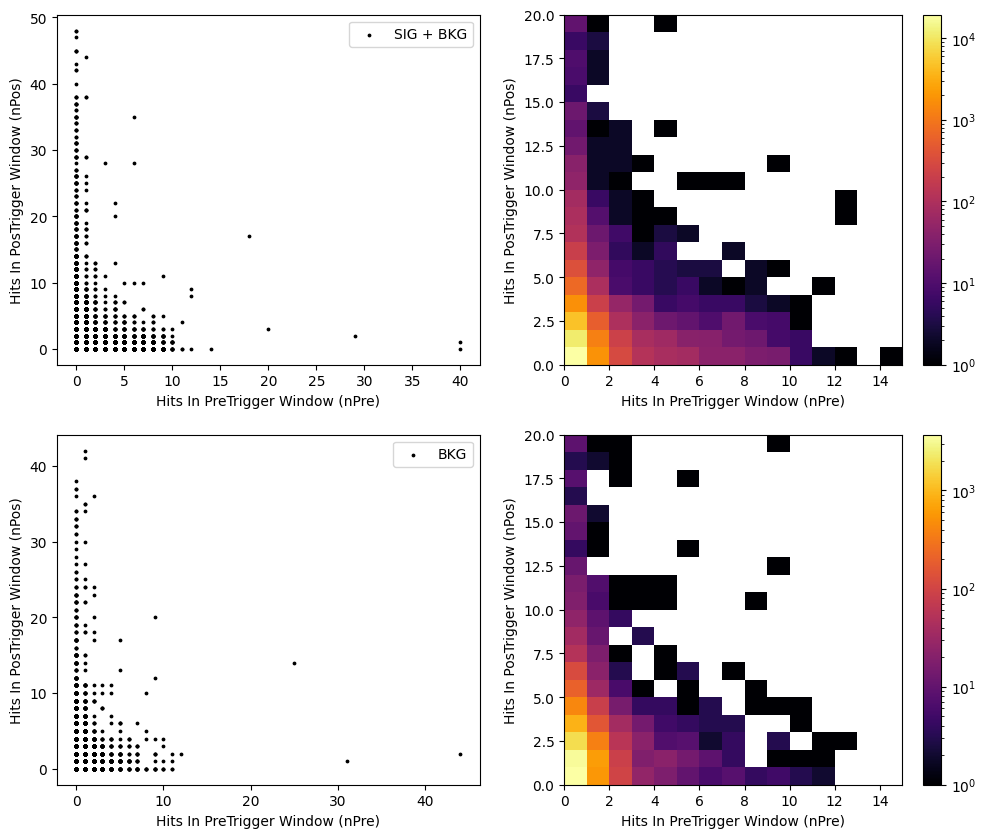

In [23]:
subplot = pltext.canvas(4)

subplot(1)
plt.scatter(noHits_in_preTrigger_sig, noHits_in_posTrigger_sig, s=3, label="SIG + BKG");
plt.xlabel("Hits In PreTrigger Window (nPre)");
plt.ylabel("Hits In PosTrigger Window (nPos)");
plt.legend();

subplot(2)
h = plt.hist2d(noHits_in_preTrigger_sig, noHits_in_posTrigger_sig, (15, 20), range=((0,15), (0, 20)), norm="log", cmap="inferno", label="SIG + BKG")
plt.colorbar(h[3]);
plt.xlabel("Hits In PreTrigger Window (nPre)");
plt.ylabel("Hits In PosTrigger Window (nPos)");

subplot(3)
plt.scatter(noHits_in_preTrigger_bkg, noHits_in_posTrigger_bkg, s=3, label="BKG");
plt.xlabel("Hits In PreTrigger Window (nPre)");
plt.ylabel("Hits In PosTrigger Window (nPos)");
plt.legend();

subplot(4)
h = plt.hist2d(noHits_in_preTrigger_bkg, noHits_in_posTrigger_bkg, (15, 20), range=((0,15), (0, 20)), norm="log", cmap="inferno", label="BKG")
plt.colorbar(h[3]);
plt.xlabel("Hits In PreTrigger Window (nPre)");
plt.ylabel("Hits In PosTrigger Window (nPos)");


In [24]:
# En la ventana larga también podemos calcular el promedio del tiempo de los hits, y la rms del tiempo de los hits. 
# Esperamos que en la señal, el promedio esté en 0, en el bkg sea mayor, y el rms de la señal sea menor que el del bkg.

hits_in_preTrigger_sig = []
hits_in_posTrigger_sig = []

for k,v in nicf_triggered_signal_hit_times_tof.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof[event] 
    seed  = nicf_d_seed_tof[event]
    roi   = nicf_d_roi_tof[event]
    # subplot = pltext.canvas(len(sett))

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask_window = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        mask_post   = (shifted_sett > (shifted_seed+20))
        mask_pre    = (shifted_sett < (shifted_seed))
        t0_20       = np.mean(shifted_sett[mask_window])

        hits_in_preTrigger_sig.append(shifted_sett[mask_pre])
        hits_in_posTrigger_sig.append(shifted_sett[mask_post])

hits_in_preTrigger_bkg = []
hits_in_posTrigger_bkg = []

for k,v in bkg_triggered_signal_hit_times_tof.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof[event] 
    seed  = bkg_d_seed_tof[event]
    roi   = bkg_d_roi_tof[event]
    # subplot = pltext.canvas(len(sett))

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask_window = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        mask_post   = (shifted_sett > (shifted_seed+20))
        mask_pre    = (shifted_sett < (shifted_seed))
        t0_20       = np.mean(shifted_sett[mask_window])

        hits_in_preTrigger_bkg.append(shifted_sett[mask_pre])
        hits_in_posTrigger_bkg.append(shifted_sett[mask_post])

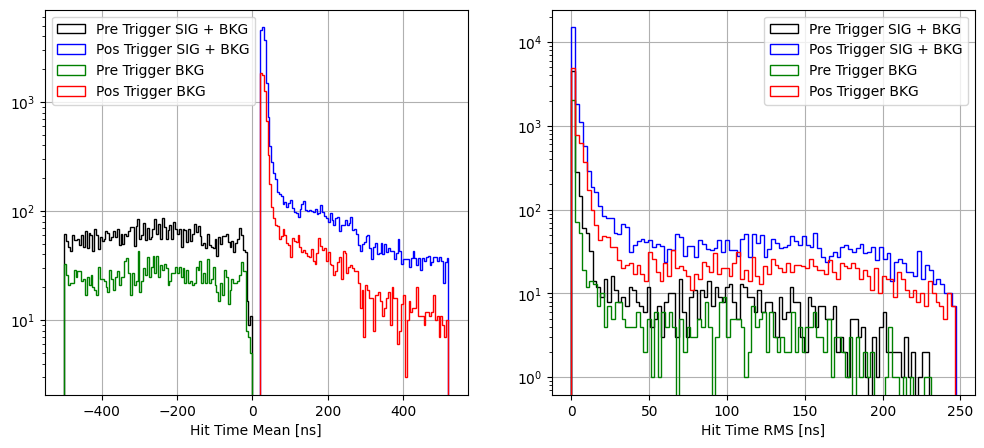

In [25]:
# En la ventana larga también podemos calcular el promedio del tiempo de los hits, y la rms del tiempo de los hits. 
# Esperamos que en la señal, el promedio esté en 0, en el bkg sea mayor, y el rms de la señal sea menor que el del bkg.

hits_in_preTrigger_mean_sig = [np.mean(j) for j in [i for i in hits_in_preTrigger_sig if len(i)!=0]]
hits_in_preTrigger_std_sig  = [np.std(j)  for j in [i for i in hits_in_preTrigger_sig if len(i)!=0]]
hits_in_posTrigger_mean_sig = [np.mean(j) for j in [i for i in hits_in_posTrigger_sig if len(i)!=0]]
hits_in_posTrigger_std_sig  = [np.std(j)  for j in [i for i in hits_in_posTrigger_sig if len(i)!=0]]

hits_in_preTrigger_mean_bkg = [np.mean(j) for j in [i for i in hits_in_preTrigger_bkg if len(i)!=0]]
hits_in_preTrigger_std_bkg  = [np.std(j)  for j in [i for i in hits_in_preTrigger_bkg if len(i)!=0]]
hits_in_posTrigger_mean_bkg = [np.mean(j) for j in [i for i in hits_in_posTrigger_bkg if len(i)!=0]]
hits_in_posTrigger_std_bkg  = [np.std(j)  for j in [i for i in hits_in_posTrigger_bkg if len(i)!=0]]

subplot = pltext.canvas(2)

subplot(1)
pltext.hist(hits_in_preTrigger_mean_sig, 100, ylog=True, xylabels="Hit Time Mean [ns]", stats=False, label="Pre Trigger SIG + BKG");
pltext.hist(hits_in_posTrigger_mean_sig, 100, ylog=True, xylabels="Hit Time Mean [ns]", stats=False, label="Pos Trigger SIG + BKG");
pltext.hist(hits_in_preTrigger_mean_bkg, 100, ylog=True, xylabels="Hit Time Mean [ns]", stats=False, label="Pre Trigger BKG");
pltext.hist(hits_in_posTrigger_mean_bkg, 100, ylog=True, xylabels="Hit Time Mean [ns]", stats=False, label="Pos Trigger BKG");

subplot(2)
pltext.hist(hits_in_preTrigger_std_sig, 100, ylog=True, xylabels="Hit Time RMS [ns]", stats=False, label="Pre Trigger SIG + BKG");
pltext.hist(hits_in_posTrigger_std_sig, 100, ylog=True, xylabels="Hit Time RMS [ns]", stats=False, label="Pos Trigger SIG + BKG");
pltext.hist(hits_in_preTrigger_std_bkg, 100, ylog=True, xylabels="Hit Time RMS [ns]", stats=False, label="Pre Trigger BKG");
pltext.hist(hits_in_posTrigger_std_bkg, 100, ylog=True, xylabels="Hit Time RMS [ns]", stats=False, label="Pos Trigger BKG");

In [26]:
# En la ventana larga también podemos calcular el promedio del tiempo de los hits, y la rms del tiempo de los hits. 
# Esperamos que en la señal, el promedio esté en 0, en el bkg sea mayor, y el rms de la señal sea menor que el del bkg.

candidates_sig = []

for k,v in nicf_triggered_signal_hit_times_tof.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof[event] 
    seed  = nicf_d_seed_tof[event]
    roi   = nicf_d_roi_tof[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        candidates_sig.append(shifted_sett)

candidates_bkg = []

for k,v in bkg_triggered_signal_hit_times_tof.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof[event] 
    seed  = bkg_d_seed_tof[event]
    roi   = bkg_d_roi_tof[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        candidates_bkg.append(shifted_sett)

candidates_sig_meanTime = [np.mean(i) for i in candidates_sig]
candidates_sig_rmsTime  = [np.std(i)  for i in candidates_sig]
candidates_sig_size     = [len(i) for i in candidates_sig]
candidates_bkg_meanTime = [np.mean(i) for i in candidates_bkg]
candidates_bkg_rmsTime  = [np.std(i)  for i in candidates_bkg]
candidates_bkg_size     = [len(i) for i in candidates_bkg]

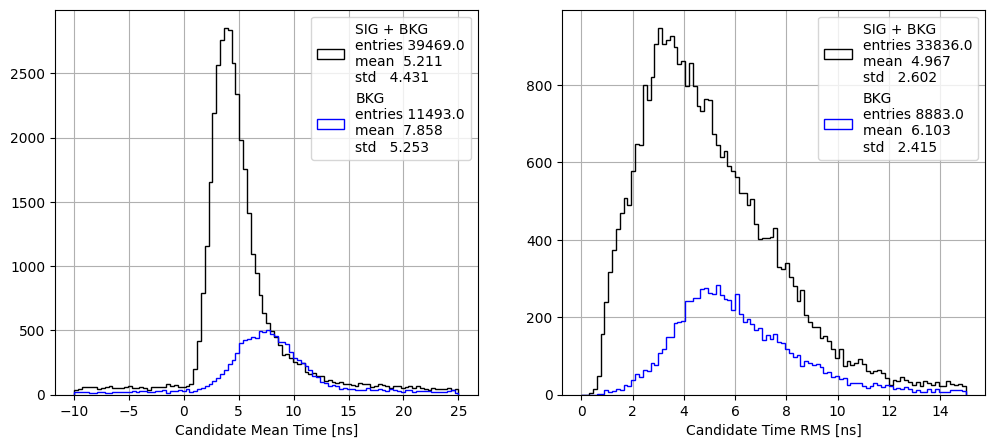

In [27]:
subplot = pltext.canvas(2)

subplot(1)
pltext.hist(candidates_sig_meanTime, 100, range=(-10, 25), ylog=False, xylabels="Candidate Mean Time [ns]", label="SIG + BKG");
pltext.hist(candidates_bkg_meanTime, 100, range=(-10, 25), ylog=False, xylabels="Candidate Mean Time [ns]", label="BKG");

subplot(2)
h = pltext.hist(candidates_sig_rmsTime, 100, range=(0, 15), ylog=False, xylabels="Candidate Time RMS [ns]", label="SIG + BKG");
pltext.hist(candidates_bkg_rmsTime, 100, range=(0, 15), ylog=False, xylabels="Candidate Time RMS [ns]", label="BKG");

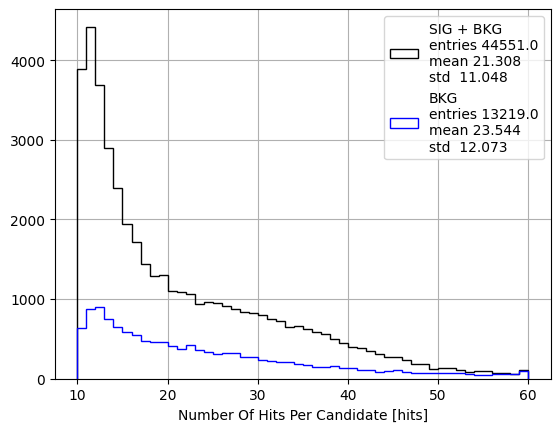

In [28]:
# Calculamos también el promedio de hits en los candidates 
pltext.hist(candidates_sig_size, 50, xylabels="Number Of Hits Per Candidate [hits]", label="SIG + BKG");
pltext.hist(candidates_bkg_size, 50, xylabels="Number Of Hits Per Candidate [hits]", label="BKG");

In [29]:
# Verificar que en una ventana más larga  (-200, 200) ns alrededor del candidato no hay otro candidato si lo hay se elimina como candidato. 
# Esto es, en esa ventana larga solo puede haber un candidato. 
# Puede que tengamos que hacer la búsqueda modificando la condición de candidato: si hay un candidato en 20 ns con nhits > 10 (esto es sin poner corte superior de 60), no usamos ese candidato. 
# ¿Cuántas veces tiramos candidatos?

number_of_subCandidates_sig = []
for k,v in tqdm(nicf_triggered_signal_hit_times_tof.items(), total=len(nicf_triggered_signal_hit_times_tof)):
    for c in range(len(v)):
        candidate_to_investigate = [nicf_triggered_signal_hit_times_tof[k][c] - nicf_d_seed_tof[k][c]]
        thresh_inf               = 10     # hits
        thresh_sup               = np.inf # hits
        sliding_window           = 20     # ns
        pre_trigger_window       = 0      # ns  
        post_trigger_window      = 0      # ns
        dead_time                = sliding_window + post_trigger_window

        test_triggered_signal_hits_index_tof, test_triggered_signal_hit_times_tof, test_d_seed_tof, test_d_roi_tof = nHits(mode="single_event", hit_times=candidate_to_investigate, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time, event=0)
        number_of_subCandidates_sig.append(len(test_triggered_signal_hit_times_tof[0]))

number_of_subCandidates_bkg = []
for k,v in tqdm(bkg_triggered_signal_hit_times_tof.items(), total=len(bkg_triggered_signal_hit_times_tof)):
    for c in range(len(v)):
        candidate_to_investigate = [bkg_triggered_signal_hit_times_tof[k][c] - bkg_d_seed_tof[k][c]]
        thresh_inf               = 10     # hits
        thresh_sup               = np.inf # hits
        sliding_window           = 20     # ns
        pre_trigger_window       = 0      # ns  
        post_trigger_window      = 0      # ns
        dead_time                = sliding_window + post_trigger_window

        test_triggered_signal_hits_index_tof, test_triggered_signal_hit_times_tof, test_d_seed_tof, test_d_roi_tof = nHits(mode="single_event", hit_times=candidate_to_investigate, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time, event=0)
        number_of_subCandidates_bkg.append(len(test_triggered_signal_hit_times_tof[0]))


  0%|          | 0/11113 [00:00<?, ?it/s]

100%|██████████| 11113/11113 [00:01<00:00, 9341.38it/s]


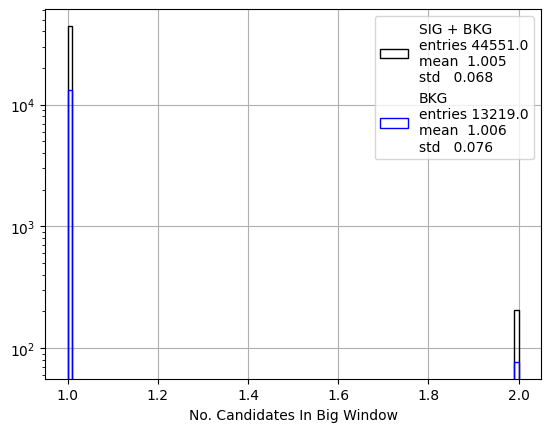

In [30]:
pltext.hist(number_of_subCandidates_sig, 100, ylog=True, xylabels="No. Candidates In Big Window", label="SIG + BKG");
pltext.hist(number_of_subCandidates_bkg, 100, ylog=True, xylabels="No. Candidates In Big Window", label="BKG");

In [31]:
sigCount = np.unique_counts(number_of_subCandidates_sig)
bkgCount = np.unique_counts(number_of_subCandidates_bkg)

In [32]:
# print(f"{sigCount[1][1]/(sigCount[1][1]+sigCount[1][2])*100:.2f}% of the candidates in SIG+BKG run have just one candidate in the big window")
# print(f"{bkgCount[1][1]/(bkgCount[1][1]+bkgCount[1][2])*100:.2f}% of the candidates in BKG run have just one candidate in the big window")

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import math

n_events = 20

with PdfPages("../test.pdf") as pdf:

    for event in tqdm(range(n_events), total=n_events):

        if len(nicf_triggered_signal_hit_times_tof[event]) == 0:
            continue
        
        sett = nicf_triggered_signal_hit_times_tof[event]
        seed = nicf_d_seed_tof[event]

        n_candidates = len(sett)

        # Definir layout automático (ej: 2 columnas)
        ncols = 2
        nrows = math.ceil(n_candidates / ncols)

        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(6*ncols, 4*nrows)
        )

        # Asegurarnos de que axes sea iterable 1D
        axes = np.atleast_1d(axes).flatten()

        for i in range(n_candidates):

            ax = axes[i]

            shifted_sett = sett[i] - seed[i]
            shifted_seed = 0.0   # porque seed[i] - seed[i] = 0

            mask = (shifted_sett > 0) & (shifted_sett < 20)

            t0_20 = np.mean(shifted_sett[mask]) if np.any(mask) else np.nan

            counts, bins, _ = ax.hist(
                shifted_sett,
                bins=100
            )

            ax.axvspan(
                shifted_seed,
                shifted_seed + 20,
                alpha=0.3
            )

            if not np.isnan(t0_20):
                ax.vlines(
                    t0_20,
                    0,
                    np.max(counts),
                    linestyles="--"
                )
                ax.legend([rf"$t_0$ = {t0_20:.2f} ns"])

            ax.set_xlabel("Candidate's Hit Times - ToF [ns]")
            ax.set_ylabel("Entries")
            ax.set_title(f"Candidate {i}")

        # Eliminar subplots vacíos si sobran
        for j in range(n_candidates, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"Example ReadoutWindow - Event {event}")
        fig.tight_layout()

        pdf.savefig(fig)
        plt.close(fig)

print("PDF creado correctamente.")

100%|██████████| 20/20 [00:23<00:00,  1.16s/it]

PDF creado correctamente.


# Filter Candidates Using On Time Region

In [34]:
# pltext.hist(t_tof_to_20_sig[0] + t0_20_sig[0], 100, range=(0,30));
# pltext.hist(nicf_triggered_signal_hit_times_tof[0][0] - nicf_d_seed_tof[0][0], 100);
# pltext.hist(arr[genericMask] + t0_20_sig[0], 100, range=(0,30));

In [35]:
all_indices = []
for k,v in nicf_triggered_signal_hits_index_tof.items():
    all_indices.append(v)
all_times = []
for k,v in t_tof_to_20_sig.items():
    all_times.append(v)

In [36]:
len(all_indices), len(all_times)

(11113, 11113)

In [37]:
onTimeCandidates = []

for i, (candidates, indices) in enumerate(zip(all_times, all_indices)):
    # print(i)
    onTimeCandidate = []

    for candidate, indice in zip(candidates, indices):

        if len(candidate) != len(indice):
            continue
            
        arr  = candidate
        mask = (arr < 15) & (arr > -10)

        onTimeCandidate.append(indice[mask])

    onTimeCandidates.append(onTimeCandidate)

In [38]:
realCandidates = []
for i in tqdm(range(len(nicf_run_tof_corrected_times)), total=len(nicf_run_tof_corrected_times)):
    for j in onTimeCandidates[i]:
        realCandidates.append(nicf_run_tof_corrected_times[i][j])

realPosIds = []
for i in tqdm(range(len(nicf_run_tof_hit_position_ids)), total=len(nicf_run_tof_hit_position_ids)):
    for j in onTimeCandidates[i]:
        realPosIds.append(nicf_run_tof_hit_position_ids[i][j])

realSlotIds = []
for i in tqdm(range(len(nicf_run_tof_hit_slot_ids)), total=len(nicf_run_tof_hit_slot_ids)):
    for j in onTimeCandidates[i]:
        realSlotIds.append(nicf_run_tof_hit_slot_ids[i][j])

100%|██████████| 11113/11113 [00:09<00:00, 1136.73it/s]


In [39]:
realCandidates = ak.Array(realCandidates)
realPosIds     = ak.Array(realPosIds)
realSlotIds    = ak.Array(realSlotIds)

In [40]:
events           = np.arange(0, len(realCandidates))
n_hits_per_event = ak.num(realCandidates)
events           = np.repeat(events, n_hits_per_event)

In [41]:
times                = ak.to_numpy(ak.ravel(realCandidates))
slot_ids             = ak.to_numpy(ak.ravel(realSlotIds))
position_ids         = ak.to_numpy(ak.ravel(realPosIds))

In [42]:
data = np.column_stack([
        events,
        times,
        slot_ids,
        position_ids
    ])

In [43]:
import pandas as pd

df = pd.DataFrame(data, columns=["event_id", "times", "slots", "positions"])

In [44]:
df["pmt_id"] = df["slots"]*19 + df["positions"]

In [45]:
df

,event_id,times,slots,positions,pmt_id
0,0.0,87708.689924,92.0,12.0,1760.0
1,0.0,87708.896821,92.0,13.0,1761.0
2,0.0,87709.065982,92.0,14.0,1762.0
3,0.0,87709.129391,90.0,17.0,1727.0
4,0.0,87709.588260,92.0,5.0,1753.0
...,...,...,...,...,...
894565,44550.0,190018.184888,20.0,17.0,397.0
894566,44550.0,190018.206837,6.0,7.0,121.0
894567,44550.0,190018.209405,1.0,1.0,20.0
894568,44550.0,190018.213652,62.0,4.0,1182.0


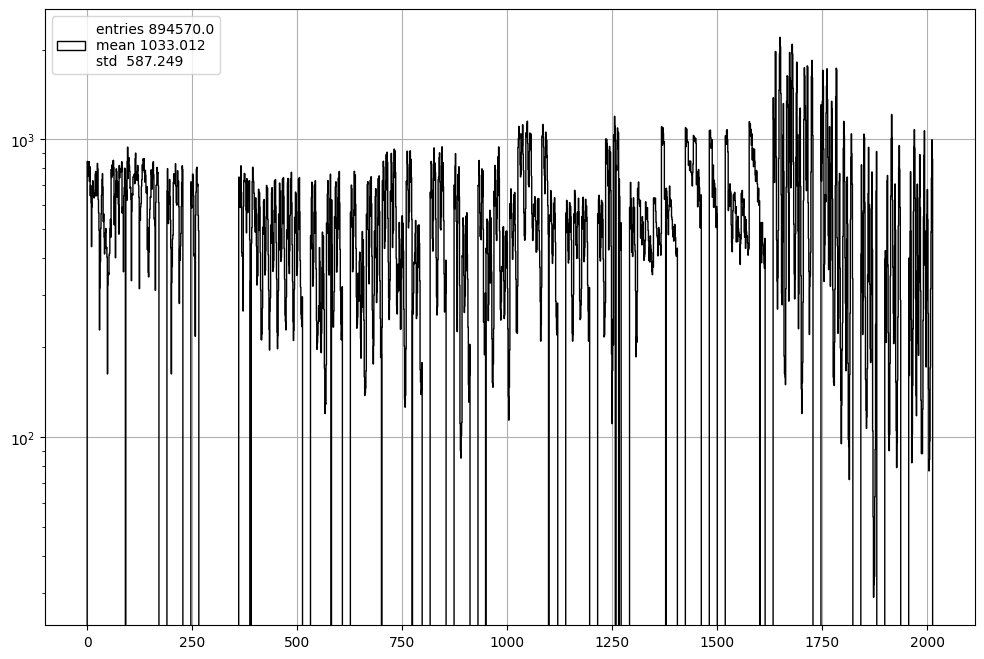

In [46]:
fig = plt.figure(figsize=(12, 8))

pltext.hist(df["pmt_id"], 2014, ylog=True);

# Read MC Data

In [47]:
from WCSimFilePackages.npz_to_df import simple_truehits_info_to_df, digihits_info_to_df

npz_down = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/npz/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1767_CDSON_15kevents.npz'
nevents  = 15000

# Creación del DataFrame de DigiHits usando la función digihits_info_to_df
df_trueHits_down = simple_truehits_info_to_df(npz_down).dropna()
df_digiHits_down = digihits_info_to_df(npz_down, nevents).dropna()

In [48]:
from WCTE_event_display.EventDisplay      import EventDisplay

#1) make an instance of the event display class
eventDisplay = EventDisplay() 

#2) start by loading in the CSV file for how the mPMTs are mapped to 2d event display
#unwraps based on the mPMT slot ID 
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')

#mask out mPMT slots - newer WCSim doesn't have these mPMTs loaded  
#WCTE slot numbering
# eventDisplay.mask_mPMTs([45,77,79,27,32,85,91,99,12,14,16,18])
#WCSim container numbering
# eventDisplay.mask_mPMTs([20,73,38,49,55,65,67,33,71,92,101,95])

#3) load the WCSim mapping tube no to slot number
#for WCSim using the numpy output we need the mapping between the tube_number in WCSim and the slot and mPMT number in the detector
#this can be obtained from the geofile that WCSim produces 
#This changes if the CDS is implemented or not
eventDisplay.load_wcsim_tubeno_mapping("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt")

In [49]:
import json

# Cargar los datos de gaps del análisis anterior
with open('/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim_old/install/npz/gap_analysis_data.json', 'r') as f:
    gap_data = json.load(f)
    
invalid_pmt_id = []
for i in range(len(gap_data["gaps_detalle"])):
    invalid_pmt_id.append(gap_data["gaps_detalle"][i]["numeros_faltantes"])

invalid_pmt_id = np.concatenate(invalid_pmt_id)

In [50]:
no_candidates_sig = df.event_id.nunique()
no_candidates_mc  = df_digiHits_down.event_id.nunique()

print(no_candidates_mc, no_candidates_sig)

14935 44551


In [51]:
mc = df_digiHits_down
tube_no = mc["digi_hit_pmt"] + 1
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
mc_pmt_id = mPMT_id_1771 * 19 + PMT_pos_1771

df_digiHits_down["pmt_id"] = mc_pmt_id

mc_pmt_id = np.array(
    [pmt for pmt in mc_pmt_id if pmt not in invalid_pmt_id]
)

print(len(mc["event_id"].unique()))

[40 40 40 ... 53 51 51]
14935


In [52]:
ps = df_digiHits_down.groupby("pmt_id")["digi_hit_charge"].sum().index.to_numpy(dtype=int)
cs = df_digiHits_down.groupby("pmt_id")["digi_hit_charge"].sum().to_numpy()
count = df_digiHits_down.groupby("pmt_id")["digi_hit_charge"].count().to_numpy()
mcss = np.zeros(2014)
mcss[ps] = cs
countmc = np.zeros(2014)
countmc[ps] = count

In [53]:
pmts_sig = df["pmt_id"]

sig_hits_per_pmt = np.bincount(
    pmts_sig.astype(int),
    minlength=2014
)

pure_signal = sig_hits_per_pmt

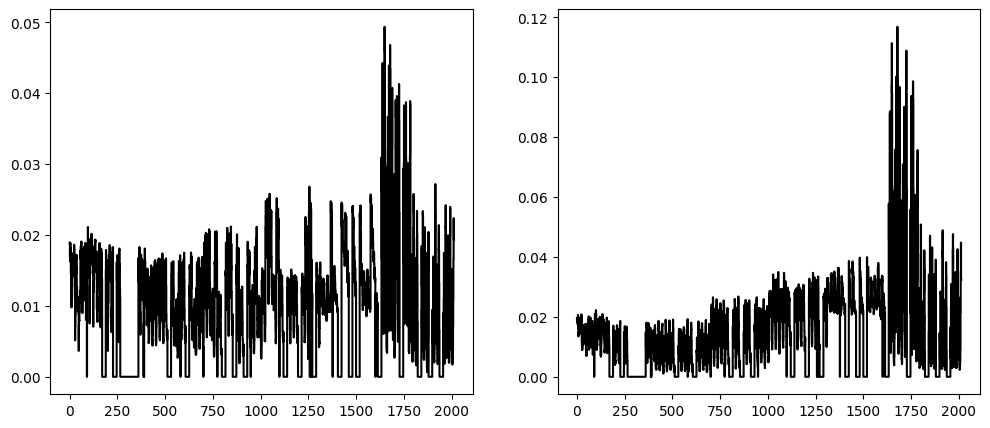

In [54]:
subplot = pltext.canvas(2)

subplot(1)
plt.step(range(2014), pure_signal/no_candidates_sig);

subplot(2)
mc_signal = np.bincount(mc_pmt_id, minlength=2014)

plt.step(range(2014), mc_signal/no_candidates_mc);

# Compare Data VS. MC

#### RQE

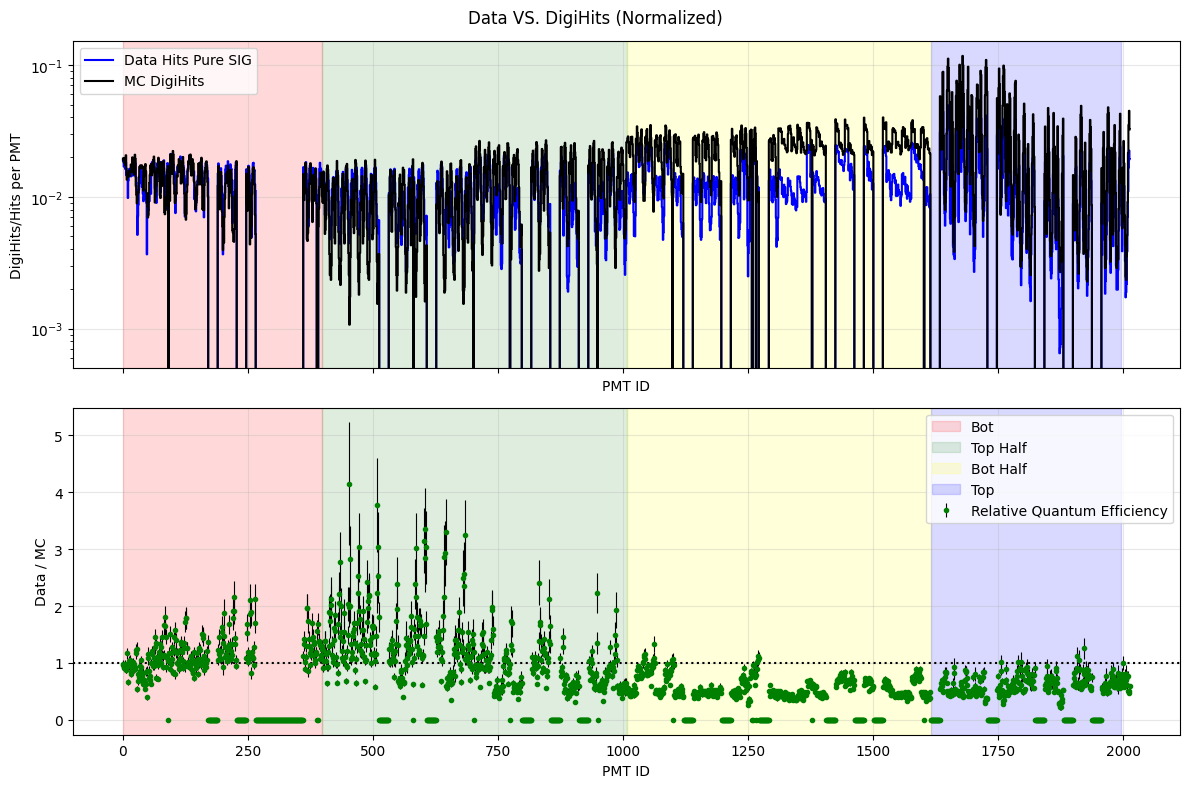

In [55]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2,2]}
)

# --- DigiHits por PMT ---
ax1.step(range(2014), pure_signal/no_candidates_sig,    where="mid", color="blue",  label="Data Hits Pure SIG")
ax1.step(range(2014), mc_signal/no_candidates_mc, where="mid", color="black", label="MC DigiHits")

ax1.set_yscale("log")
ax1.set_ylabel("DigiHits/Hits per PMT")
ax1.set_xlabel("PMT ID")
ax1.axvspan(0, 21*19,      color="red",         alpha=0.15)
ax1.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax1.axvspan(53*19, 85*19,  color="yellow",      alpha=0.15)
ax1.axvspan(85*19, 105*19, color="blue",        alpha=0.15)
ax1.legend()
ax1.grid(alpha=0.3)

# --- Hits por PMT normalizados ---
N_data = pure_signal          # conteos por PMT
N_mc   = mc_signal            # conteos por PMT

data_hits_per_pmt = N_data / no_candidates_sig
mc_hits_per_pmt   = N_mc   / no_candidates_mc

# --- Errores Poissonianos por bin ---
error_data = np.zeros(2014)
error_mc   = np.zeros(2014)

mask_data = N_data > 0
mask_mc   = N_mc   > 0

error_data[mask_data] = np.sqrt(N_data[mask_data]) / no_candidates_sig
error_mc[mask_mc]     = np.sqrt(N_mc[mask_mc])   / no_candidates_mc

# --- Ratio Data / MC y su error ---
relative_qe       = np.zeros(2014)
error_relative_qe = np.zeros(2014)

mask = (mc_hits_per_pmt > 0) & (data_hits_per_pmt > 0)

relative_qe[mask] = data_hits_per_pmt[mask] / mc_hits_per_pmt[mask]

error_relative_qe[mask] = np.sqrt(
    (error_data[mask] / mc_hits_per_pmt[mask])**2
    +
    (data_hits_per_pmt[mask] * error_mc[mask] / mc_hits_per_pmt[mask]**2)**2
)

ax2.errorbar(
    range(2014),
    relative_qe,
    yerr=error_relative_qe,
    fmt="o",
    markersize=3,
    markerfacecolor="green",
    markeredgecolor="green",
    ecolor="black",        # color de las barras de error
    elinewidth=0.8,
    capsize=0,
    label="Relative Quantum Efficiency"
)
# ax2.scatter(range(2014), relative_qe, color="green", s=2, label="Relative Quantum Efficiency", zorder=2)
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT ID")
ax2.grid(alpha=0.3)
# ax2.set_ylim(-2, 4)
plt.legend()

# --- Regiones del detector ---
ax2.axvspan(0, 21*19,      color="red",         alpha=0.15, label="Bot")
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15, label="Top Half")
ax2.axvspan(53*19, 85*19,  color="yellow",      alpha=0.15, label="Bot Half")
ax2.axvspan(85*19, 105*19, color="blue",        alpha=0.15, label="Top")
ax2.legend()

plt.suptitle("Data VS. DigiHits (Normalized)", y=0.98)
plt.tight_layout()

In [56]:
# np.savez("data_files/nobkgrun_pure_signal_1771.npz",      pure_signal);
# np.savez("data_files/nobkgrun_mc_signal_1771.npz",        mc_signal);
# np.savez("data_files/nobkgrun_sig_noCandidates_1771.npz", no_candidates_sig);
# np.savez("data_files/nobkgrun_mc_noCandidates_1771.npz",  no_candidates_mc);

# Investigate 60 bin nHits

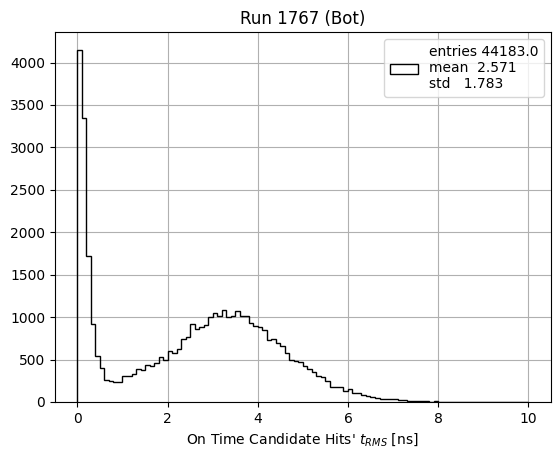

In [57]:
pltext.hist(df.groupby("event_id")["times"].std(), 100, ylog=False, range=(0, 10), xylabels=r"On Time Candidate Hits' $t_{RMS}$ [ns]");
plt.title("Run 1767 (Bot)");

In [58]:
def nHits(mode,
          hit_times,
          w,
          thresh_min,
          thresh_max,
          pre_window,
          post_window,
          jump,
          event=0,
          progress_bar=True):

    def process_event(ht,
                      w,
                      thresh_min,
                      thresh_max,
                      pre_window,
                      post_window,
                      jump):

        if len(ht) == 0:
            return [], [], [], []

        # Orden temporal
        ht = np.sort(ht)

        # ------------------------
        # Sliding window trigger
        # ------------------------

        ends  = ht + w
        right = np.searchsorted(ht, ends, side="left")
        left  = np.arange(len(ht))
        counts = right - left

        trigger_indices = np.where(counts >= thresh_min)[0]

        triggered_hits_index = []
        triggered_hits_time = []

        trigger_seeds = []      # t_seed (paper SLE crossing)
        roi_start_times = []   # primer hit físico del cluster

        last_cluster_end = -np.inf

        # ------------------------
        # Loop triggers
        # ------------------------

        for idx in trigger_indices:

            t_seed = ht[idx]

            # Deadtime basado en CLUSTER REAL
            if t_seed < last_cluster_end + jump:
                continue

            # ------------------------
            # ROI física
            # ------------------------

            t_min = t_seed - pre_window
            t_max = t_seed + w + post_window

            roi_mask = (ht >= t_min) & (ht <= t_max)
            indices_roi = np.where(roi_mask)[0]

            if len(indices_roi) < thresh_min:
                continue

            # Protección de memoria (opcional)
            if thresh_max is not None and len(indices_roi) > thresh_max:
                indices_roi = indices_roi[:thresh_max]

            hit_times_roi = ht[indices_roi]

            # ------------------------
            # Guardado
            # ------------------------

            triggered_hits_index.append(indices_roi)
            triggered_hits_time.append(hit_times_roi)

            trigger_seeds.append(t_seed)
            roi_start_times.append(hit_times_roi[0])

            # Deadtime real: fin del cluster físico
            last_cluster_end = hit_times_roi[-1]

        return triggered_hits_index, triggered_hits_time, trigger_seeds, roi_start_times

    # ==================================================
    # SINGLE EVENT
    # ==================================================

    if mode == "single_event":

        ht = ak.to_numpy(hit_times[event])

        idxs, times, seeds, roi_starts = process_event(
            ht,
            w,
            thresh_min,
            thresh_max,
            pre_window,
            post_window,
            jump
        )

        return ({event: idxs},
                {event: times},
                {event: seeds},
                {event: roi_starts})

    # ==================================================
    # MULTIPLE EVENTS
    # ==================================================

    elif mode == "multiple_events":

        nevents = len(hit_times)

        triggered_hits_index = {}
        triggered_hits_time = {}
        trigger_seeds_dict = {}
        roi_start_times_dict = {}

        for event in tqdm(range(nevents),
                          total=nevents,
                          leave=progress_bar):

            ht = ak.to_numpy(hit_times[event])

            if len(ht) == 0:
                triggered_hits_index[event] = []
                triggered_hits_time[event] = []
                trigger_seeds_dict[event] = []
                roi_start_times_dict[event] = []
                continue

            idxs, times, seeds, roi_starts = process_event(
                ht,
                w,
                thresh_min,
                thresh_max,
                pre_window,
                post_window,
                jump
            )

            triggered_hits_index[event] = idxs
            triggered_hits_time[event] = times
            trigger_seeds_dict[event] = seeds
            roi_start_times_dict[event] = roi_starts

        return (triggered_hits_index,
                triggered_hits_time,
                trigger_seeds_dict,
                roi_start_times_dict)

    else:
        print("enter a valid mode name")
        return {}, {}, {}, {}


In [59]:
ht = nicf_noSpill_times_tof[0]
w  = 20
thresh_min = 10

ends  = ht + w
right = np.searchsorted(ht, ends, side="left")
left  = np.arange(len(ht))
counts = right - left

trigger_indices = np.where(counts >= thresh_min)[0]

triggered_hits_index = []
triggered_hits_time  = []

trigger_seeds   = []   # t_seed (paper SLE crossing)
roi_start_times = []   # primer hit físico del cluster

last_cluster_end = -np.inf

In [60]:
np.where(counts >= thresh_min)[0]

<Array [27, 28, 29, 30, 31, ..., 291, 292, 293, 294, 295] type='45 * int64'>